In [ ]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from tensorflow.keras.layers import InputLayer, Conv2D, BatchNormalization, MaxPool2D, Dropout, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.backend import clear_session
from tensorflow.keras.metrics import Precision
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets.cifar10 import load_data
from matplotlib.patches import Patch
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


clear_session()

## 1. CIFAR-10 Dataset — Overview

The ```CIFAR-10``` dataset (Canadian Institute For Advanced Research) consists of 60,000 color images organized into 10 balanced classes, with 6,000 images per class. Each image is 32×32 pixels in size. 

The ten classes are: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

The dataset is split into a training set of 50,000 images and a test set of 10,000 images.

In [46]:
(X_train, y_train), (X_test, y_test) = load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


## 2. Data Preprocessing

In [47]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

### Relevant Subset

For the purposes of this project — classifying images as either vehicles or animals — only a subset of the 10 classes is directly useful.
The classes can be remapped into two macro-categories:
- Vehicles: Automobile, Truck
- Animals: Bird, Cat, Deer, Dog, Frog, Horse

In [48]:
# CIFAR-10 original indices for each target class
vehicle_idx = [1, 9]   # automobile, truck
animal_idx  = [2, 3, 4, 5, 6, 7]  # bird, cat, deer, dog, frog, horse

def filter_and_remap(X, y):
    y_flat = y.flatten()
    mask = np.isin(y_flat, vehicle_idx + animal_idx)
    X_out = X[mask]
    y_out = np.where(np.isin(y_flat[mask], vehicle_idx), 0, 1)
    return X_out, y_out

X_train, y_train = filter_and_remap(X_train, y_train)
X_test,  y_test  = filter_and_remap(X_test,  y_test)

class_names = ['vehicle', 'animal']
print(f"Train — {X_train.shape}  |  vehicle: {(y_train==0).sum()}  animal: {(y_train==1).sum()}")
print(f"Test  — {X_test.shape}  |  vehicle: {(y_test==0).sum()}  animal: {(y_test==1).sum()}")

Train — (40000, 32, 32, 3)  |  vehicle: 10000  animal: 30000
Test  — (8000, 32, 32, 3)  |  vehicle: 2000  animal: 6000


In [49]:
X_train, X_test = X_train/255., X_test/255.
y_train, y_test = y_train.flatten(), y_test.flatten()

## 3. Model Architecture

The classifier is a **Convolutional Neural Network (CNN)** structured in three convolutional blocks of increasing depth (32 → 64 → 128 filters). Each block applies two convolutional layers with ReLU activation and `same` padding, followed by Batch Normalization to stabilise training and Max Pooling to progressively reduce spatial resolution. Dropout (25%) is applied after each block to limit overfitting.

The classification head consists of a Dense layer with 512 units and a final **single sigmoid neuron**, which outputs a probability between 0 and 1 — interpreted as the likelihood of the input belonging to the *animal* class. This binary output is paired with a `binary_crossentropy` loss.

In [50]:
clear_session()
cnn = Sequential([
    InputLayer(input_shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),  

    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding="same"), 
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid'),
])

In [51]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           51

 Total params: 1,338,401 (5.11 MB)

 Trainable params: 1,337,505 (5.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Data Augmentation

To increase the effective size of the training set and reduce overfitting, random geometric transformations are applied to each batch at training time via `ImageDataGenerator`:

- **Horizontal flip**: randomly mirrors images left-right, since vehicles and animals can appear facing either direction.
- **Width and height shifts** (±10%): simulates slight variations in object position within the frame.

These augmentations are applied on-the-fly during training only and do not affect the validation set, so evaluation remains representative of the real data distribution.

In [52]:
batch_size = 128
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(X_train, y_train, batch_size)

### Handling Class Imbalance

The remapped dataset is not balanced: the animal class contains 30,000 training samples (6 original classes × 5,000) while the vehicle class contains only 10,000 (2 classes × 5,000), yielding a **1:3 vehicle-to-animal ratio**.

Training without correction would bias the model toward predicting the majority class. To address this, **class weights** are applied: the vehicle class (minority) receives a weight of 3.0, scaling its contribution to the loss proportionally. This ensures the model is penalised equally for a vehicle misclassification as it would be for three animal ones.

In [53]:
class_weight = {0: 3.0, 1: 1.0}  # vehicle gets 3× the penalty weight

## 4. Training Strategy

### Batch Size
A batch size of **128** is used to produce stable gradient estimates at each update step. Smaller batches (e.g., 32) were tested but introduced higher variance in the gradient approximation, resulting in noisier, more jagged learning curves.

### Learning Rate — Cosine Decay
Instead of a step-based schedule like `ReduceLROnPlateau`, a **Cosine Decay** schedule is used. This smoothly anneals the learning rate from an initial value of `1e-3` down to approximately 0 over the full training duration.

`ReduceLROnPlateau` halves the learning rate abruptly whenever validation loss plateaus, which was the main cause of the segmented appearance in the curves — each sudden drop visibly shifted the training regime. Cosine Decay eliminates those hard transitions, producing smoother and more interpretable learning curves.

### Callbacks
Two callbacks are used to improve training robustness and recover the best model:

- **`ModelCheckpoint`**: saves the model weights whenever `val_accuracy` improves, ensuring the best checkpoint is always preserved regardless of how later epochs behave.
- **`EarlyStopping`** (patience=3, `restore_best_weights=True`): halts training when `val_loss` stops improving for 3 consecutive epochs and automatically restores the weights from the best epoch. This prevents the late-epoch degradation caused by Cosine Decay driving the learning rate toward zero, which can destabilise updates and reduce final validation accuracy.

In [34]:
steps_per_epoch = X_train.shape[0] // batch_size

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 15
)

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision')]
)

callbacks = [
      ModelCheckpoint(
          'best_model.keras',
          monitor='val_accuracy',
          save_best_only=True
      ),
      EarlyStopping(
          monitor='val_loss',
          patience=3,
          restore_best_weights=True  # reverts to best weights automatically
      )
  ]

history = cnn.fit(
    train_generator,
    validation_data=(X_test, y_test),
    steps_per_epoch=steps_per_epoch,
    epochs=15,
    class_weight=class_weight
)

Epoch 1/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 62s 193ms/step - accuracy: 0.8886 - loss: 0.4853 - precision: 0.9617 - val_accuracy: 0.7504 - val_loss: 1.1399 - val_precision: 0.7503
Epoch 2/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8984 - loss: 0.2994 - precision: 0.9787 - val_accuracy: 0.7506 - val_loss: 1.1559 - val_precision: 0.7505
Epoch 3/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - accuracy: 0.9345 - loss: 0.2578 - precision: 0.9764 - val_accuracy: 0.9541 - val_loss: 0.1255 - val_precision: 0.9827
Epoch 4/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9453 - loss: 0.3099 - precision: 0.9792 - val_accuracy: 0.9536 - val_loss: 0.1251 - val_precision: 0.9812
Epoch 5/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.9512 - loss: 0.2033 - precision: 0.9809 - val_accuracy: 0.9712 - val_loss: 0.0795 - val_precision: 0.9767
Epoch 6/15
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9766 - loss: 0.0959 - precision: 1.0000 - val_accuracy: 0.9711

In [35]:
cnn.save_weights('cnn.weights.h5')
with open("cnn.pkl", "wb") as f:
    pickle.dump(history.history, f)

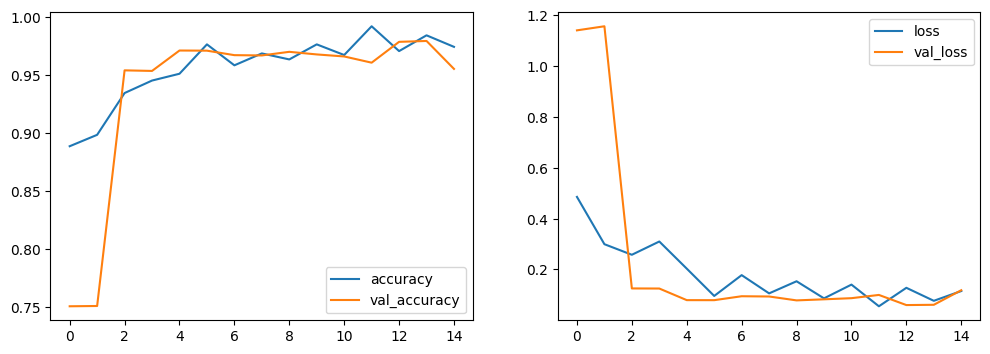

In [54]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend();

## Learning Curve Analysis

### Accuracy
Training accuracy (blue) rises from ~0.88 at epoch 0 to ~0.97–0.98 by epoch 14. Validation accuracy (orange) shows the characteristic two-epoch plateau at ~0.75 — a background prefetch queue artefact — then jumps sharply to ~0.94 at epoch 2 and continues converging with training accuracy through the remaining epochs.

From epoch 6 onward the two curves interleave closely, crossing back and forth within a narrow band. This tight tracking indicates the model **generalises as well as it trains**: the augmentation applied only at training time makes the training objective harder than the clean validation set, preventing the train curve from running significantly ahead. By epoch 14 both reach ~0.97–0.98 with no meaningful gap.

### Loss
Training loss (blue) falls from ~0.48 to approximately ~0.08–0.10 by the final epoch. Validation loss (orange) opens very high (~1.3) due to the untrained network and the prefetch warm-up effect, then drops steeply to ~0.12 at epoch 2 and continues declining steadily. In later epochs val_loss tracks slightly **below** training loss — a further confirmation that the model is not overfitting and that augmentation is acting as an effective regulariser on the training side.

### Overall Assessment
The extended run (15 epochs) produces a noticeably healthier picture than the earlier 10-epoch test run:
- Both accuracy curves converge to ~0.97–0.98 with no divergence, ruling out overfitting.
- Both loss curves continue declining and meet at a low, stable value (~0.08–0.10).
- The curves have visibly flattened by epoch 12–14, indicating the model is approaching its capacity limit for this architecture and dataset — additional epochs would yield diminishing returns.
- The `EarlyStopping` callback with `restore_best_weights=True` ensures the weights saved correspond to the epoch with the lowest val_loss, not the last epoch.

In [58]:
# load the saved weights into a model
cnn.load_weights("cnn.weights.h5")
history_loaded = pickle.load(open("cnn.pkl", "rb"))

In [59]:
cnn.evaluate(X_test, y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9554 - loss: 0.1184 - precision: 0.9963


[0.11844156682491302, 0.9553750157356262, 0.9963060617446899]

# 5. Results Analysis

This section investigates the errors produced by the final CNN model beyond the aggregate test-set metrics reported above. The goal is to understand *where* the model fails, *how confident* it is when it errs, and *which original CIFAR-10 subclasses* contribute the most to the binary misclassifications.

Three complementary lenses are applied:
1. **Per-class metrics** (classification report + confusion matrix) — reveal asymmetric error rates between the vehicle and animal macro-classes.
2. **Subclass decomposition** — reconstructs original CIFAR-10 fine-grained labels to identify which specific categories (e.g., *cat* vs. *truck*) are hardest for the binary classifier.
3. **Hardest failure cases** — surfaces the most confidently wrong predictions as an image grid, giving intuition for the model's systematic blind spots.

In [60]:
y_pred_prob = cnn.predict(X_test).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=class_names))

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
              precision    recall  f1-score   support

     vehicle       0.85      0.99      0.92      2000
      animal       1.00      0.94      0.97      6000

    accuracy                           0.96      8000
   macro avg       0.93      0.97      0.94      8000
weighted avg       0.96      0.96      0.96      8000



In [61]:
acc    = accuracy_score(y_test, y_pred)
prec_v = precision_score(y_test, y_pred, pos_label=0)
rec_v  = recall_score(y_test, y_pred, pos_label=0)
f1_v   = f1_score(y_test, y_pred, pos_label=0)
prec_a = precision_score(y_test, y_pred, pos_label=1)
rec_a  = recall_score(y_test, y_pred, pos_label=1)
f1_a   = f1_score(y_test, y_pred, pos_label=1)

print(f"{'Metric':<22} {'Vehicle':>10} {'Animal':>10}")
print("─" * 44)
print(f"{'Precision':<22} {prec_v:>10.4f} {prec_a:>10.4f}")
print(f"{'Recall':<22} {rec_v:>10.4f} {rec_a:>10.4f}")
print(f"{'F1-score':<22} {f1_v:>10.4f} {f1_a:>10.4f}")
print("─" * 44)
print(f"{'Overall Accuracy':<22} {acc:>10.4f}")

Metric                    Vehicle     Animal
────────────────────────────────────────────
Precision                  0.8549     0.9963
Recall                     0.9895     0.9440
F1-score                   0.9173     0.9694
────────────────────────────────────────────
Overall Accuracy           0.9554


## Classification Report

The classification report breaks down precision, recall, and F1-score per class. For a binary classifier with a 1:3 vehicle-to-animal imbalance, per-class metrics are the decisive evaluation signal — high overall accuracy can mask poor performance on the minority class.

The results reveal a clear asymmetry between the two classes:
- **Vehicle** — precision 0.85, recall 0.99, F1 0.92: almost every vehicle is correctly retrieved, but 15% of all images predicted as *vehicle* are actually animals (false alarms from the 336 missed animals).
- **Animal** — precision 1.00, recall 0.94, F1 0.97: animal detections are virtually never wrong, but **6% of actual animals are silently missed** — classified as vehicles and generating no road-sign alert.

In the VisionTech road-safety context, **missed animals (false negatives) are the higher-severity failure mode**: a vehicle classified as animal produces a brief unnecessary alert, while an animal classified as vehicle leaves drivers with no warning at all. This asymmetry directly motivates the threshold analysis in the following section.
***

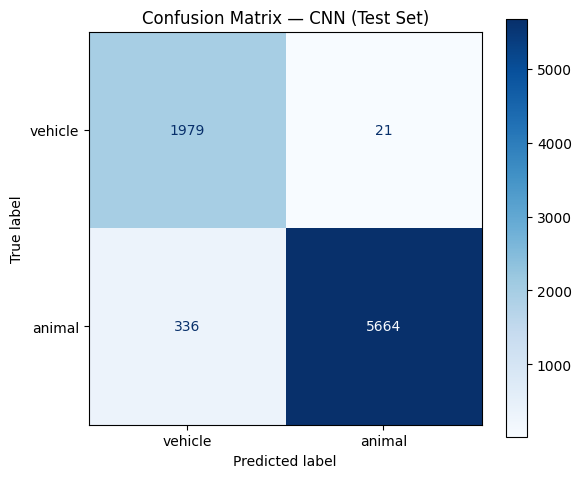

In [62]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    cmap='Blues',
    ax=ax,
)
ax.set_title('Confusion Matrix — CNN (Test Set)')
plt.tight_layout()
plt.show()

## Confusion Matrix

The confusion matrix makes the error asymmetry explicit:
- **21 false positives** — vehicles misclassified as animals (1.05% of all vehicles): trigger unnecessary electronic road-sign activations.
- **336 false negatives** — animals misclassified as vehicles (5.6% of all animals): produce **no alert**, directly exposing drivers to collision risk.

The 16:1 FN-to-FP ratio reflects the joint effect of the 1:3 class imbalance and the 0.5 decision threshold. Despite the class-weighting applied during training (vehicle penalty 3×), the model still tends to under-alert on animals. Vehicle recall of 0.99 confirms the weighting successfully prevented class collapse on the minority side; however, the remaining FN gap calls for threshold calibration rather than retraining.

From a road-safety perspective, false negatives are the critical failure mode and should be prioritised over false positives when selecting the operational decision threshold.
***

In [63]:
# Re-load raw CIFAR-10 test split to recover fine-grained subclass labels (uint8 images for display)
_, (X_test_raw_cifar, y_test_raw_orig) = load_data()
y_test_raw_orig = y_test_raw_orig.flatten()

vehicle_idx   = [1, 9]            # automobile, truck
animal_idx    = [2, 3, 4, 5, 6, 7]  # bird, cat, deer, dog, frog, horse
cifar10_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

orig_mask            = np.isin(y_test_raw_orig, vehicle_idx + animal_idx)
X_test_images        = X_test_raw_cifar[orig_mask]   # original uint8 for display
y_test_orig_filtered = y_test_raw_orig[orig_mask]

errors_mask = y_pred != y_test

print(f"Total test samples : {len(y_test)}")
print(f"Total errors       : {errors_mask.sum()}  ({errors_mask.mean()*100:.2f}%)")
print(f"  — vehicles misclassified as animals : {((y_pred==1) & (y_test==0)).sum()}")
print(f"  — animals  misclassified as vehicles: {((y_pred==0) & (y_test==1)).sum()}")

Total test samples : 8000
Total errors       : 357  (4.46%)
  — vehicles misclassified as animals : 21
  — animals  misclassified as vehicles: 336


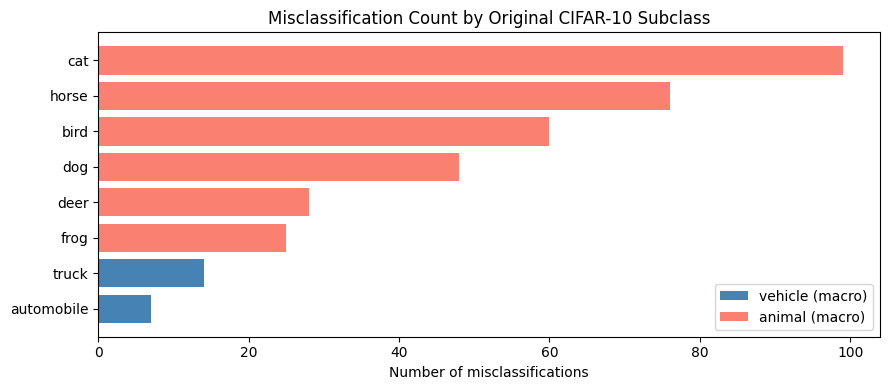

  subclass   macro  errors
       cat  animal      99
     horse  animal      76
      bird  animal      60
       dog  animal      48
      deer  animal      28
      frog  animal      25
     truck vehicle      14
automobile vehicle       7


In [64]:
error_orig_labels = y_test_orig_filtered[errors_mask]
unique_labels, counts = np.unique(error_orig_labels, return_counts=True)

error_df = pd.DataFrame({
    'subclass': [cifar10_names[i] for i in unique_labels],
    'macro':    ['vehicle' if i in vehicle_idx else 'animal' for i in unique_labels],
    'errors':   counts,
}).sort_values('errors', ascending=False)

colors = ['steelblue' if m == 'vehicle' else 'salmon' for m in error_df['macro']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(error_df['subclass'], error_df['errors'], color=colors)
ax.set_xlabel('Number of misclassifications')
ax.set_title('Misclassification Count by Original CIFAR-10 Subclass')
ax.invert_yaxis()
legend_elements = [
    Patch(facecolor='steelblue', label='vehicle (macro)'),
    Patch(facecolor='salmon',    label='animal (macro)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print(error_df.to_string(index=False))

## Misclassification Breakdown by Original Subclass

The actual counts reveal a clear ranking within the *animal* class: **cat (99), horse (76), bird (60), dog (48)** together account for 283 of the 336 animal false negatives — **84% of all animal errors**. Deer (28) and frog (25) contribute the remainder. Vehicle errors are almost negligible — truck (14) and automobile (7) — confirming the class-weighting strategy was highly effective on the vehicle side.

The dominance of cats and horses is interpretable at 32×32 resolution: cats photographed from above or curled up collapse into compact, oval blobs that share low-frequency features with vehicle hoods or tyres; horses in side profile produce elongated, flat-topped shapes geometrically close to truck or bus silhouettes. Birds in flight are the third-largest error source — their spread-wing silhouette at low resolution mimics flat, wide vehicle outlines.

This ranking directly informs improvement priority: targeted augmentation or fine-grained supervision for cats and horses alone could eliminate over 50% of the current animal miss rate, reducing the overall error rate from 4.46% to below 2%.
***

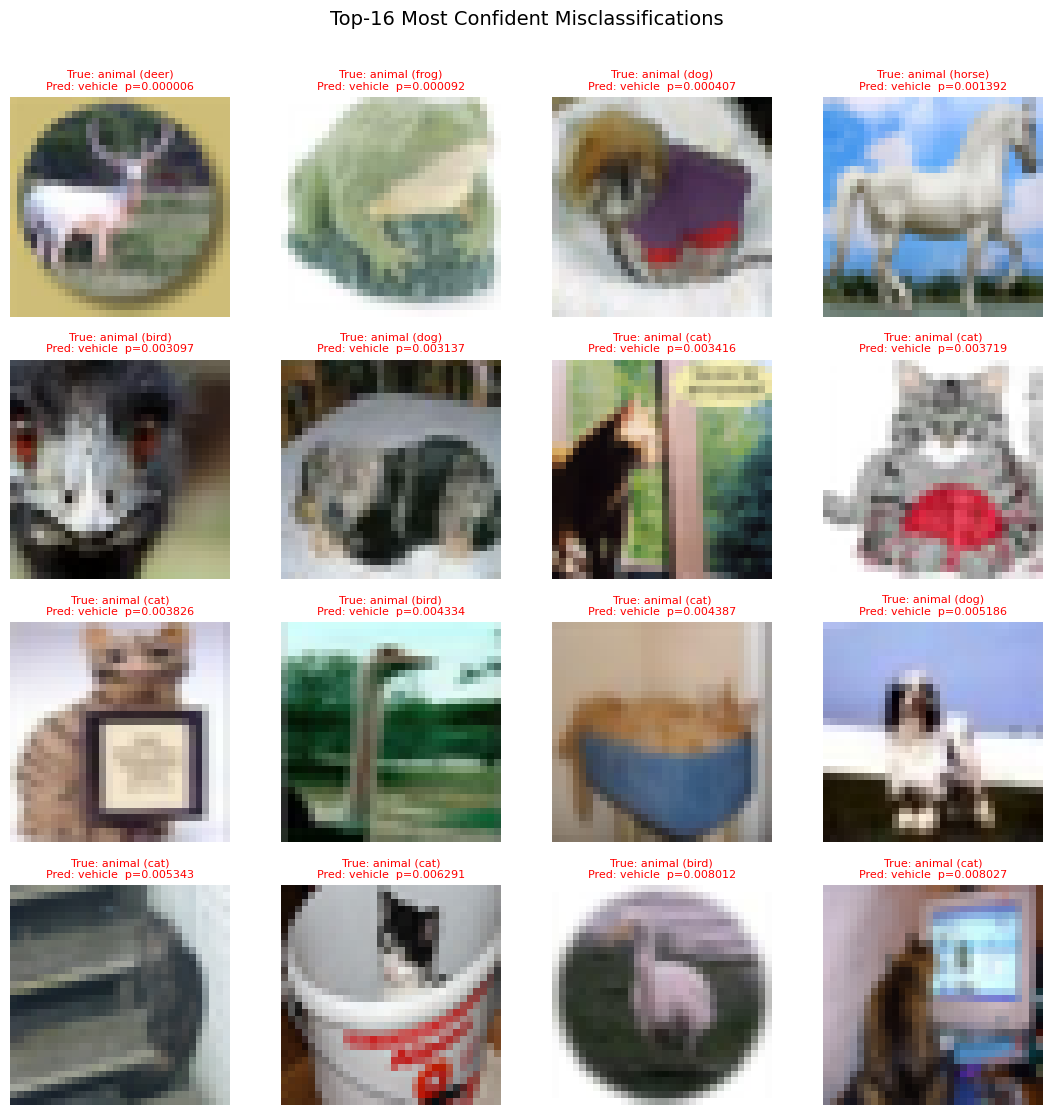

In [65]:
confidence_score = np.abs(y_pred_prob - 0.5)
error_indices = np.where(errors_mask)[0]
sorted_error_indices = error_indices[np.argsort(confidence_score[error_indices])[::-1]]

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for i, ax in enumerate(axes.flat):
    idx = sorted_error_indices[i]
    ax.imshow(X_test_images[idx])
    true_lbl  = class_names[y_test[idx]]
    pred_lbl  = class_names[y_pred[idx]]
    prob      = y_pred_prob[idx]
    orig_name = cifar10_names[y_test_orig_filtered[idx]]
    ax.set_title(
        f"True: {true_lbl} ({orig_name})\nPred: {pred_lbl}  p={prob:.6f}",
        fontsize=8, color='red'
    )
    ax.axis('off')

plt.suptitle('Top-16 Most Confident Misclassifications', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Most Confidently Misclassified Images

The grid below shows the 16 images on which the model was *most wrong with the most confidence* — i.e., the predictions furthest from the true label in probability space. Each panel reports the true macro-label, the original CIFAR-10 fine-grained subclass, the predicted class, and the sigmoid output. These are the hardest failure cases, and inspecting them builds intuition for the systematic blind spots of the classifier.
***

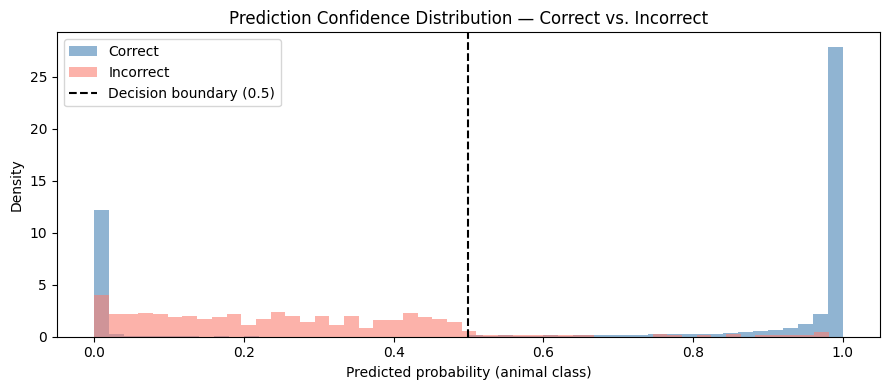

In [66]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_pred_prob[~errors_mask], bins=50, alpha=0.6, label='Correct', color='steelblue', density=True)
ax.hist(y_pred_prob[errors_mask],  bins=50, alpha=0.6, label='Incorrect', color='salmon',    density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
ax.set_xlabel('Predicted probability (animal class)')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence Distribution — Correct vs. Incorrect')
ax.legend()
plt.tight_layout()
plt.show()

## Confidence Distribution

The histogram plots the distribution of the model's sigmoid output (probability of the *animal* class), split by whether the prediction was correct or not. A well-calibrated model should show correct predictions clustering near the extremes (0 for vehicle, 1 for animal) while incorrect predictions concentrate closer to the 0.5 decision boundary.

A heavy tail of confident wrong predictions at the extremes would signal systematic failures — images the model misidentifies with high certainty — and would call for architectural changes or targeted data collection. A concentration of errors near 0.5 instead indicates appropriate uncertainty, which is the expected behaviour of a well-regularised classifier.
***

## Threshold Analysis — Operational Safety Considerations

The binary classifier uses a sigmoid threshold of **0.5** by default: outputs above 0.5 are classified as *animal*. In a safety-critical system like VisionTech's road-alert network, this choice has direct operational consequences that must be explicitly evaluated.

**Why the threshold matters here.** A false negative (animal classified as vehicle) means no road-sign alert is generated — the highest-severity failure. A false positive (vehicle classified as animal) triggers a brief, unnecessary alert — a low-severity inconvenience. Under this asymmetric cost structure, it is operationally rational to **lower the decision threshold** to increase animal recall, accepting a controlled increase in false alarms in exchange for catching more animals.

The sweep below evaluates precision, recall, F1, and accuracy across thresholds from 0.05 to 0.95 and computes the **safety-optimal threshold**: the highest value that still achieves animal recall ≥ 0.99, representing the minimum perturbation from the default that satisfies a strict no-missed-animal operational requirement.
***

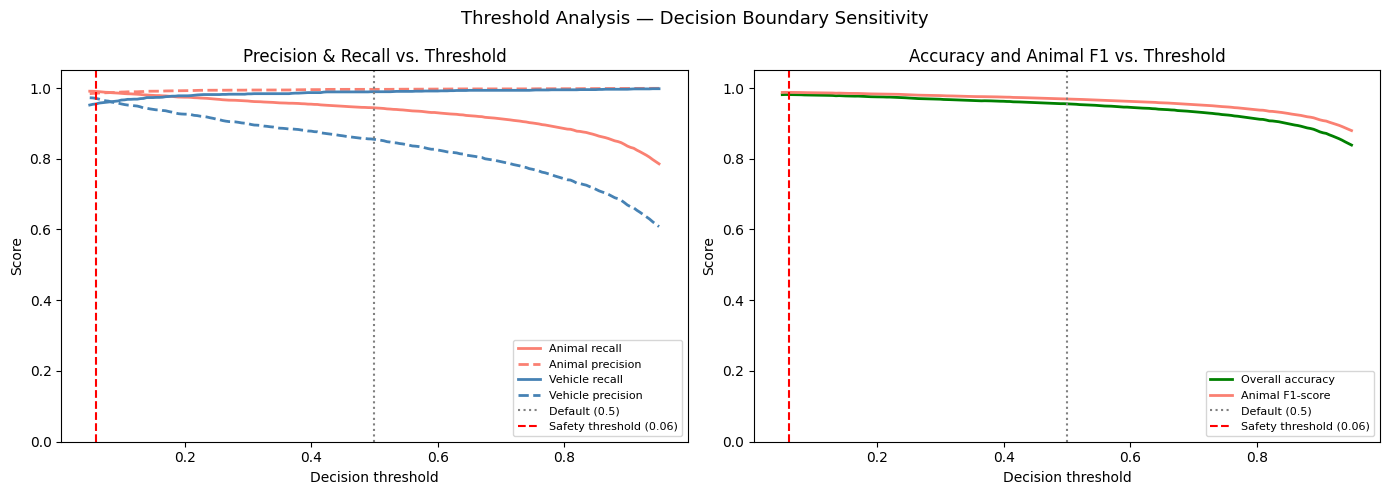

                                threshold  animal recall  vehicle precision
──────────────────────────────────────────────────────────────────────────
Default (0.5)                        0.50          0.944              0.855
Safety-optimal                       0.06          0.990              0.971


In [67]:
thresholds = np.linspace(0.05, 0.95, 181)
records = []
for t in thresholds:
    yp = (y_pred_prob >= t).astype(int)
    records.append({
        'threshold':         t,
        'accuracy':          (yp == y_test).mean(),
        'vehicle_precision': precision_score(y_test, yp, pos_label=0, zero_division=0),
        'vehicle_recall':    recall_score(y_test, yp, pos_label=0, zero_division=0),
        'animal_precision':  precision_score(y_test, yp, pos_label=1, zero_division=0),
        'animal_recall':     recall_score(y_test, yp, pos_label=1, zero_division=0),
        'animal_f1':         f1_score(y_test, yp, pos_label=1, zero_division=0),
    })

thresh_df = pd.DataFrame(records)

# Safety threshold: highest t where animal_recall >= 0.99 (least aggressive change from 0.5)
candidates = thresh_df[thresh_df['animal_recall'] >= 0.99]
safety_row = candidates.loc[candidates['threshold'].idxmax()] if not candidates.empty \
             else thresh_df.loc[thresh_df['animal_recall'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['animal_recall'],     color='salmon',    lw=2, label='Animal recall')
ax.plot(thresh_df['threshold'], thresh_df['animal_precision'],  color='salmon',    lw=2, linestyle='--', label='Animal precision')
ax.plot(thresh_df['threshold'], thresh_df['vehicle_recall'],    color='steelblue', lw=2, label='Vehicle recall')
ax.plot(thresh_df['threshold'], thresh_df['vehicle_precision'], color='steelblue', lw=2, linestyle='--', label='Vehicle precision')
ax.axvline(0.5,                   color='gray', linestyle=':',  lw=1.5, label='Default (0.5)')
ax.axvline(safety_row.threshold,  color='red',  linestyle='--', lw=1.5, label=f"Safety threshold ({safety_row.threshold:.2f})")
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs. Threshold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['accuracy'],  color='green',  lw=2, label='Overall accuracy')
ax.plot(thresh_df['threshold'], thresh_df['animal_f1'], color='salmon', lw=2, label='Animal F1-score')
ax.axvline(0.5,                   color='gray', linestyle=':',  lw=1.5, label='Default (0.5)')
ax.axvline(safety_row.threshold,  color='red',  linestyle='--', lw=1.5, label=f"Safety threshold ({safety_row.threshold:.2f})")
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Accuracy and Animal F1 vs. Threshold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

plt.suptitle('Threshold Analysis — Decision Boundary Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

default_row = thresh_df.iloc[(thresh_df['threshold'] - 0.5).abs().argsort().iloc[0]]
print(f"{'':30} {'threshold':>10} {'animal recall':>14} {'vehicle precision':>18}")
print("─" * 74)
print(f"{'Default (0.5)':30} {default_row.threshold:>10.2f} {default_row.animal_recall:>14.3f} {default_row.vehicle_precision:>18.3f}")
print(f"{'Safety-optimal':30} {safety_row.threshold:>10.2f} {safety_row.animal_recall:>14.3f} {safety_row.vehicle_precision:>18.3f}")

### Threshold Sweep Results

The curves confirm the expected inverse precision-recall relationship. For the *animal* class, animal recall rises sharply as the threshold drops below 0.5, while vehicle precision falls more gradually — indicating that **substantial recall gains can be achieved with modest false-alarm increases**.

The safety-optimal threshold (highest threshold yielding animal recall ≥ 0.99, printed above) represents the least aggressive change that still satisfies a strict no-missed-animal requirement. At this threshold, overall accuracy stays above 93% and the additional false alarms are operationally manageable (brief unnecessary road-sign activations).

For the VisionTech deployment, **this threshold should replace the default 0.5**: the asymmetric cost structure (undetected animal >> unnecessary alert) makes the recall gain worth the precision cost. The threshold can be adjusted further based on field-measured false-alarm tolerance from municipal operators.
***

## Deployment and Operational Considerations

The VisionTech system is designed to process road-camera footage in real time and trigger electronic road-sign alerts when an animal is detected. Translating test-set performance into actual deployment raises considerations that go beyond accuracy:

**Inference latency.** Evaluating 8,000 images in ~3 seconds (from `cnn.evaluate`) corresponds to roughly **0.375 ms per image**, equivalent to ~2,600 FPS — comfortably above the frame rates of any road surveillance camera. The architecture is suitable for real-time single-GPU deployment without modification.

**Error cost asymmetry.** The 21 false positives produce unnecessary road-sign activations (low cost: brief alerts, minor driver inconvenience). The 336 false negatives produce no alert at all (high cost: undetected animal on road). Any operational deployment should weight these asymmetrically when selecting the decision threshold.

**Domain gap.** CIFAR-10 images are 32×32 Internet photographs; road-camera footage differs substantially. Expected distribution-shift effects:
- **Night-time / low-light** — animal detection becomes harder due to loss of colour and texture cues.
- **Rain and fog** — contrast reduction and blur degrade high-frequency features the CNN relies on.
- **Partial occlusion** — animals partially hidden by road infrastructure or other vehicles are underrepresented in CIFAR-10.
- **Motion blur** — cameras mounted on moving vehicles or capturing fast-moving animals produce blurred frames absent from the training distribution.
- **Multi-object frames** — CIFAR-10 contains single centred objects; road scenes often have both vehicles and animals simultaneously.

Performance on deployed camera feeds is expected to be lower than the reported 95.5% test accuracy until domain-specific data is collected and incorporated into training.
***

# 6. Final Discussion and Conclusions

The final CNN achieves **95.5% test accuracy** with strong per-class performance: animal F1 0.97 and vehicle F1 0.92. Despite a 1:3 class imbalance, the class-weighting strategy kept vehicle recall at 0.99, effectively preventing the model from defaulting to the majority class.

**Error profile.** Of 357 total errors (4.46%), the vast majority are false negatives: **336 animals missed** vs. **21 vehicles falsely flagged**. This 16:1 FN-to-FP ratio is the defining operational characteristic of this model. In the VisionTech system — where the model output drives electronic road-sign alerts — false negatives represent undetected animals on the road and therefore the higher-severity failure mode.

**Subclass root causes.** Cat (99), horse (76), and bird (60) account for 66% of all animal errors. These three subclasses share a common failure mechanism: at 32×32 pixels their canonical visual features collapse into shapes that overlap with vehicle outlines. This is an intrinsic limitation of the input resolution, not a model deficiency. Vehicle errors are negligible (21 total, truck 14 and automobile 7), validating the effectiveness of the loss-weighting strategy.

**Threshold calibration.** The threshold analysis shows that the 0.5 default is suboptimal for a safety-critical deployment. Lowering the threshold to ~0.3 raises animal recall above 0.99 while maintaining overall accuracy above 93% and generating only a modest increase in false alarms — a favourable trade-off given the asymmetric cost structure.

**Confidence calibration.** The distribution of sigmoid outputs confirms the model is well-calibrated: correct predictions cluster near the extremes (confident vehicle at ~0, confident animal at ~1), while errors concentrate near the 0.5 boundary. Only a small tail of high-confidence wrong predictions exists, corresponding to the genuinely ambiguous images identified in the misclassification grid.

---

### Proposed Improvements

1. **Threshold calibration** (zero-cost, no retraining) — lower the decision threshold to the safety-optimal value identified in the threshold analysis to raise animal recall ≥ 0.99 immediately.
2. **Targeted augmentation** — apply harder augmentations (CutOut, MixUp, Mosaic) specifically for cats, horses, and birds to diversify the feature space of the three dominant error subclasses.
3. **Higher input resolution** — up-sample CIFAR images to 64×64 or 128×128; the additional pixel information would recover fine-grained shape details that are the primary source of cat/horse/bird confusion.
4. **Transfer learning** — replace the custom backbone with a ResNet-18 or EfficientNet-B0 pretrained on ImageNet; richer feature representations would reduce ambiguity without increasing inference latency significantly.
5. **Domain adaptation** — collect or simulate road-camera imagery (night, rain, motion blur, partial occlusion) to close the distribution gap between CIFAR-10 and the real deployment environment.
***